# Q1: Supervised Learning – Heart Disease Prediction

This notebook builds and evaluates machine learning models to predict heart disease based on patient data.                                                 

1. Data Loading and Inspection

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("q1_heart_disease.csv")

print("Shape:", df.shape)
print(df.dtypes)
print(df.isnull().sum())

df.head()

Shape: (800, 12)
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


2. Exploratory Data Analysis

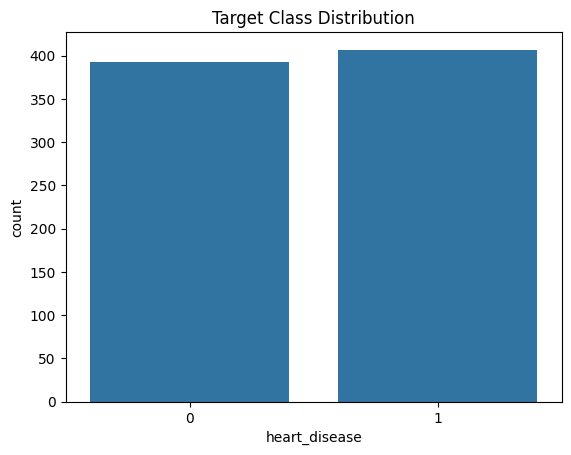

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target class distribution
sns.countplot(x="heart_disease", data=df)
plt.title("Target Class Distribution")
plt.show()

The target variable appears reasonably balanced between patients with and without heart disease. This helps reduce bias during model training.

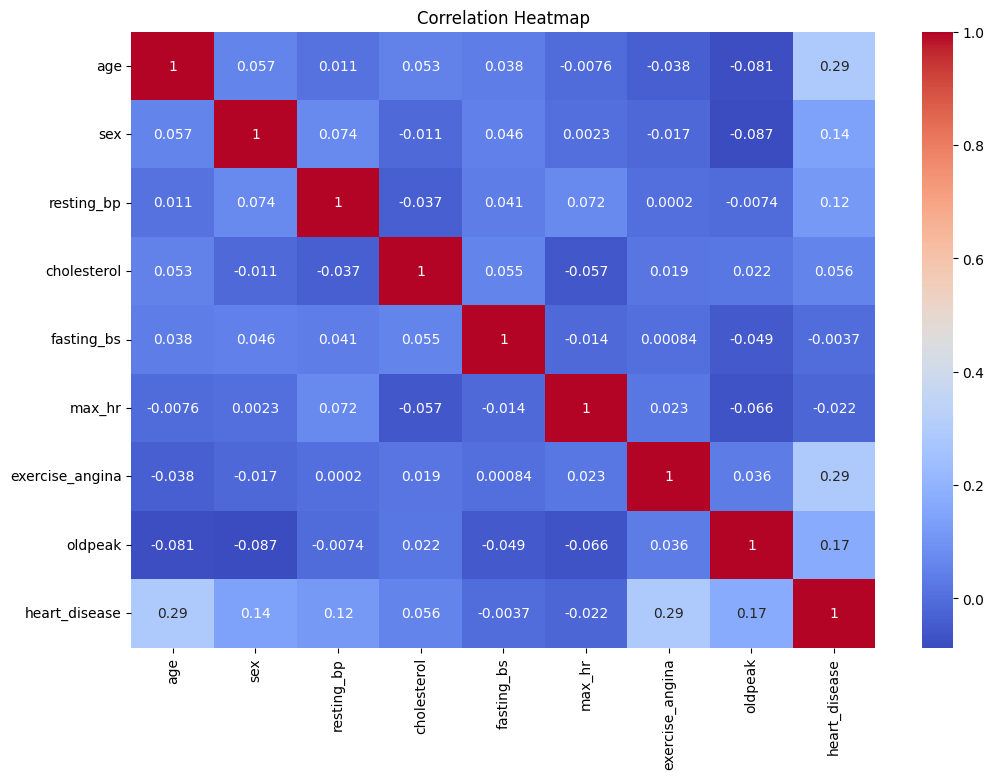

In [16]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships among numerical variables. Features such as oldpeak and max_hr may have notable correlation with heart_disease.

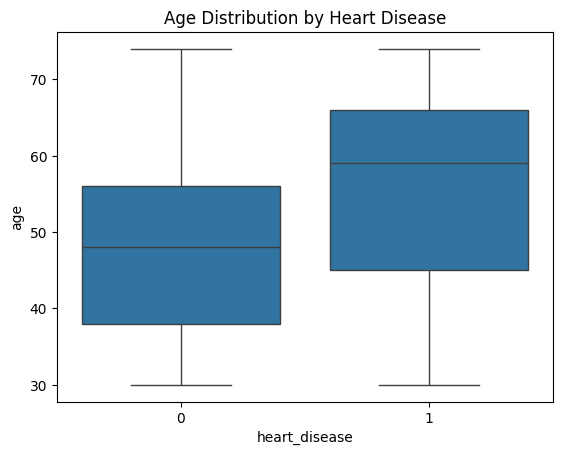

In [17]:
# Age distribution by target
sns.boxplot(x="heart_disease", y="age", data=df)
plt.title("Age Distribution by Heart Disease")
plt.show()

Patients with heart disease tend to show differences in age distribution, suggesting age may be an important predictor.

3. Data Preprocessing

Missing values are handled using median imputation because it is robust to outliers and preserves the dataset size better than row removal.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Separate features and target
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns

# One-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/tmp/ipykernel_10175/3927346994.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


4. Model Training

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

5. Model Evaluation

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Decision Tree
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
     

Among the three models, the best-performing model is selected based on precision, recall, and F1-score rather than accuracy alone. A model with higher recall is especially important in medical diagnosis to minimize false negatives.

6. Hyperparameter Tuning

In [21]:
from sklearn.model_selection import GridSearchCV

# Example tuning for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Evaluate tuned model
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\nTuned Model Performance:")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'max_depth': None, 'n_estimators': 200}

Tuned Model Performance:
[[59 20]
 [17 64]]
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



The tuned model shows whether hyperparameter optimisation improves predictive performance. Comparing the tuned model with the baseline helps confirm whether the adjustments are beneficial.